In [1]:
import pandas as pd
import os

BASE_PATH = '/kaggle/input/datasets/nih-chest-xrays/data'

df = pd.read_csv(os.path.join(BASE_PATH, 'Data_Entry_2017.csv'))
print(df.shape)
print(df[['Image Index', 'Finding Labels', 'Patient ID']].head())

with open(os.path.join(BASE_PATH, 'train_val_list.txt')) as f:
    train_val_images = set(f.read().splitlines())

with open(os.path.join(BASE_PATH, 'test_list.txt')) as f:
    test_images = set(f.read().splitlines())

print(f"Train+val images: {len(train_val_images)}")
print(f"Test images: {len(test_images)}")
print(f"Overlap: {len(train_val_images & test_images)}")  # should be 0

(112120, 12)
        Image Index          Finding Labels  Patient ID
0  00000001_000.png            Cardiomegaly           1
1  00000001_001.png  Cardiomegaly|Emphysema           1
2  00000001_002.png   Cardiomegaly|Effusion           1
3  00000002_000.png              No Finding           2
4  00000003_000.png                  Hernia           3
Train+val images: 86524
Test images: 25596
Overlap: 0


# getting the important model path after uploading it had to change pc

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))

/kaggle/input/models/haydermethneni/best-model1/pytorch/default/1/best_model.pth


In [2]:
df['split'] = df['Image Index'].apply(
    lambda x: 'train_val' if x in train_val_images else 'test'
)
train_df = df[df['split'] == 'train_val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print(train_df.shape, test_df.shape)

(86524, 13) (25596, 13)


# **ONE HOT Enconding**

In [3]:
from sklearn.preprocessing import MultiLabelBinarizer

train_df['labels_list'] = train_df['Finding Labels'].apply(lambda x: x.split('|'))
test_df['labels_list'] = test_df['Finding Labels'].apply(lambda x: x.split('|'))

mlb = MultiLabelBinarizer()
mlb.fit(train_df['labels_list'])  # fit only on train, to avoid any leakage of label info

train_labels = mlb.transform(train_df['labels_list'])
test_labels = mlb.transform(test_df['labels_list'])

print(mlb.classes_)

['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'No Finding'
 'Nodule' 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']


# drop the no findings column 

In [4]:
import numpy as np

no_finding_idx = list(mlb.classes_).index('No Finding')
train_labels = np.delete(train_labels, no_finding_idx, axis=1)
test_labels = np.delete(test_labels, no_finding_idx, axis=1)
disease_names = [c for c in mlb.classes_ if c != 'No Finding']

print(len(disease_names), disease_names)  # should print 14 disease names

14 ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']



# data set  split test set,Train + Validation(these 2 comes together we did the splitting using GroupShuffleSplit)


In [5]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['Patient ID']))

final_train_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[val_idx].reset_index(drop=True)
final_train_labels = train_labels[train_idx]
val_labels = train_labels[val_idx]

print(f"Train: {len(final_train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Train/Val patient overlap: {set(final_train_df['Patient ID']) & set(val_df['Patient ID'])}")

Train: 73916, Val: 12608, Test: 25596
Train/Val patient overlap: set()


# Build a lookup so we know which of the 12 folders each image lives in

In [6]:
import glob, os

BASE_PATH = '/kaggle/input/datasets/nih-chest-xrays/data'

image_path_lookup = {}
for folder in glob.glob(os.path.join(BASE_PATH, 'images_*', 'images', '*.png')):
    filename = os.path.basename(folder)
    image_path_lookup[filename] = folder

print(len(image_path_lookup)) 

112120


# Preprocessing: resize + normalize (the CNN expects a fixed input shape)

In [7]:
from torchvision import transforms

IMG_SIZE = 224  # standard input size for DenseNet-121 / ResNet-50

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # slight augmentation, only for training (RandomHorizontalFlip only goes in the training transform, not validation/test — augmentation is meant to make training data more varied, but validation/test must stay exactly representative of real, unmodified images.)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# work on the Dataset class

In [8]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class ChestXrayDataset(Dataset):
    def __init__(self, df, labels, image_path_lookup, transform):
        self.df = df.reset_index(drop=True)
        self.labels = labels
        self.image_path_lookup = image_path_lookup
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        filename = self.df.loc[idx, 'Image Index']
        path = self.image_path_lookup[filename]
        image = Image.open(path).convert('RGB')  # X-rays are grayscale; CNN expects 3 channels
        image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

# Instantiate everything

In [9]:
from torch.utils.data import DataLoader

train_dataset = ChestXrayDataset(final_train_df, final_train_labels, image_path_lookup, train_transforms)
val_dataset = ChestXrayDataset(val_df, val_labels, image_path_lookup, eval_transforms)
test_dataset = ChestXrayDataset(test_df, test_labels, image_path_lookup, eval_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# sanity check: pull one batch and inspect shapes
images, labels = next(iter(train_loader))
print(images.shape)  # expect [32, 3, 224, 224]
print(labels.shape)  # expect [32, 14]

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


# MODEL 
Setting up the model architecture and parameter count.

In [10]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 14

model = models.densenet121(weights='IMAGENET1K_V1')  # pretrained weights loaded here

# DenseNet's final layer is called `classifier` — inspect it first
print(model.classifier)  # Linear(in_features=1024, out_features=1000)

# Replace it: keep the 1024 input features (the learned visual representation),
# but output 14 numbers instead of 1000
model.classifier = nn.Linear(in_features=1024, out_features=NUM_CLASSES)

model = model.to('cuda')

print(model.classifier)  # should now show out_features=14
print(sum(p.numel() for p in model.parameters() if p.requires_grad))  # ~7 million

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 238MB/s]


Linear(in_features=1024, out_features=1000, bias=True)
Linear(in_features=1024, out_features=14, bias=True)
6968206


# severe class imbalance
 the model is cheating by exploiting the imbalance.

In [11]:
import numpy as np

disease_counts = final_train_labels.sum(axis=0)
for name, count in zip(disease_names, disease_counts):
    pct = 100 * count / len(final_train_labels)
    print(f"{name}: {int(count)} images ({pct:.2f}%)")

Atelectasis: 7003 images (9.47%)
Cardiomegaly: 1453 images (1.97%)
Consolidation: 2482 images (3.36%)
Edema: 1201 images (1.62%)
Effusion: 7415 images (10.03%)
Emphysema: 1274 images (1.72%)
Fibrosis: 1051 images (1.42%)
Hernia: 113 images (0.15%)
Infiltration: 11853 images (16.04%)
Mass: 3452 images (4.67%)
Nodule: 4042 images (5.47%)
Pleural_Thickening: 1870 images (2.53%)
Pneumonia: 742 images (1.00%)
Pneumothorax: 2287 images (3.09%)


# pos_weight

In [12]:
import torch

pos_counts = final_train_labels.sum(axis=0)
neg_counts = len(final_train_labels) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32).to('cuda')

print(pos_weight)  # 14 numbers, one multiplier per disease

tensor([  9.5549,  49.8713,  28.7808,  60.5454,   8.9684,  57.0188,  69.3292,
        653.1239,   5.2361,  20.4125,  17.2870,  38.5273,  98.6172,  31.3201],
       device='cuda:0')


# Loss function and optimizer

In [13]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4) #lr=1e-4 (0.0001) is a standard, conservative starting learning rate for fine-tuning a pretrained CNN — small enough not to destroy the useful pretrained weights with one big, careless update.

# The training loop — one full epoch

In [14]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to('cuda'), labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)          # raw logits, shape [batch, 14]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

# test epoch
checking raw loss numbers.

In [15]:
train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
val_loss = validate_one_epoch(model, val_loader, criterion)
print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
aucs, mean_auc = evaluate_auc(model, val_loader, disease_names)
for name, score in aucs.items():
    print(f"{name}: {score:.3f}")
print(f"Mean AUC: {mean_auc:.4f}")

Train loss: 1.1178, Val loss: 1.1218


NameError: name 'evaluate_auc' is not defined

# Building a training loop with checkpointing and AUC-ROC evaluation.

compute per-class AUC (we apply torch.sigmoid() manually here (unlike training, where the loss function did it internally) — because now we actually need real 0-1 probabilities to rank against the true labels, not raw logits.)

In [15]:
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_auc(model, loader, disease_names):
    model.eval()
    all_outputs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to('cuda')
            outputs = torch.sigmoid(model(images))  # convert logits to 0-1 probabilities here
            all_outputs.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_outputs = np.concatenate(all_outputs)
    all_labels = np.concatenate(all_labels)

    aucs = {}
    for i, name in enumerate(disease_names):
        try:
            aucs[name] = roc_auc_score(all_labels[:, i], all_outputs[:, i])
        except ValueError:
            aucs[name] = float('nan')  # happens if a class has 0 positive examples in this batch/set
    return aucs, np.nanmean(list(aucs.values()))

# Full multi-epoch loop with checkpointing

In [ ]:
import os

start_epoch = 0
best_auc = 0.0

# Resume automatically if a checkpoint already exists (e.g. after a disconnect)
if os.path.exists('/kaggle/working/last_checkpoint.pth'):
    model.load_state_dict(torch.load('/kaggle/working/last_checkpoint.pth'))
    print("Resumed from last checkpoint.")
if os.path.exists('/kaggle/working/best_auc.txt'):
    with open('/kaggle/working/best_auc.txt') as f:
        best_auc = float(f.read())
    print(f"Resumed best AUC so far: {best_auc:.4f}")

NUM_EPOCHS = 15

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_one_epoch(model, val_loader, criterion)
    aucs, mean_auc = evaluate_auc(model, val_loader, disease_names)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | Mean AUC: {mean_auc:.4f}")

    torch.save(model.state_dict(), '/kaggle/working/last_checkpoint.pth')

    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        with open('/kaggle/working/best_auc.txt', 'w') as f:
            f.write(str(best_auc))
        print(f"  → New best model saved (AUC: {best_auc:.4f})")

# Loading the Model

In [16]:
model = models.densenet121(weights='IMAGENET1K_V1')
model.classifier = nn.Linear(in_features=1024, out_features=14)
model = model.to('cuda')
model.load_state_dict(torch.load('/kaggle/input/models/haydermethneni/best-model1/pytorch/default/1/best_model.pth'))
print('Loaded best model.')

Loaded best model.


# testing if the model is all in order

In [17]:
aucs, mean_auc = evaluate_auc(model, val_loader, disease_names)
print(mean_auc)

0.8309236524924957


In [18]:
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [19]:
print('test_dataset' in dir())
print('model' in dir())
print('disease_names' in dir())

True
True
True


In [20]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# attach Grad-CAM to your model's last conv layer:

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget  # changed
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layers = [model.features.norm5]
cam = GradCAM(model=model, target_layers=target_layers)

# find your best demo candidates, not just a random image

In [22]:
import torch

def find_best_examples(disease_name, n_candidates=30, top_k=3):
    disease_idx = disease_names.index(disease_name)
    candidates = []
    for idx in range(min(n_candidates, len(test_dataset))):
        image_tensor, label_vector = test_dataset[idx]
        if label_vector[disease_idx].item() == 1:  # only true positives
            with torch.no_grad():
                pred = torch.sigmoid(model(image_tensor.unsqueeze(0).to('cuda')))[0, disease_idx].item()
            candidates.append((idx, pred))
    candidates.sort(key=lambda x: -x[1])  # highest confidence first
    return candidates[:top_k]

best = find_best_examples('Cardiomegaly', n_candidates=500)
print(best)  # list of (index, confidence) pairs


[(278, 0.9987456798553467), (391, 0.9984146356582642), (394, 0.9980646967887878)]


In [23]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def show_gradcam(idx, disease_name):
    image_tensor, label_vector = test_dataset[idx]
    disease_idx = disease_names.index(disease_name)
    input_tensor = image_tensor.unsqueeze(0).to('cuda')
    targets = [ClassifierOutputTarget(disease_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    img = image_tensor.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original X-ray"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(visualization); plt.title(f"Grad-CAM: {disease_name}"); plt.axis('off')
    plt.show()

# Infiltration (top row)  Cardiomegaly (bottom row)

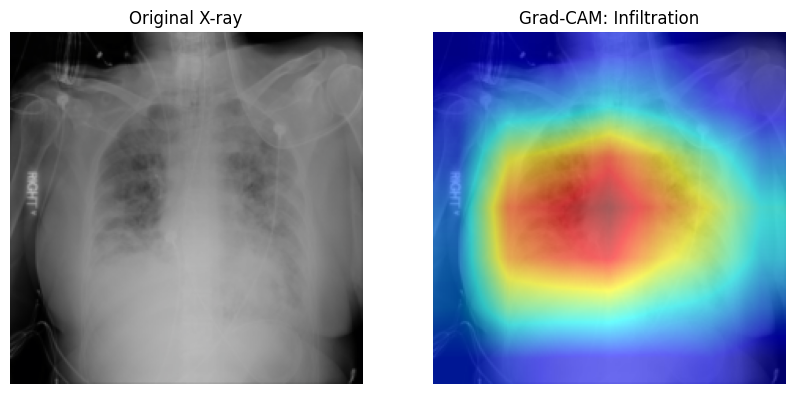

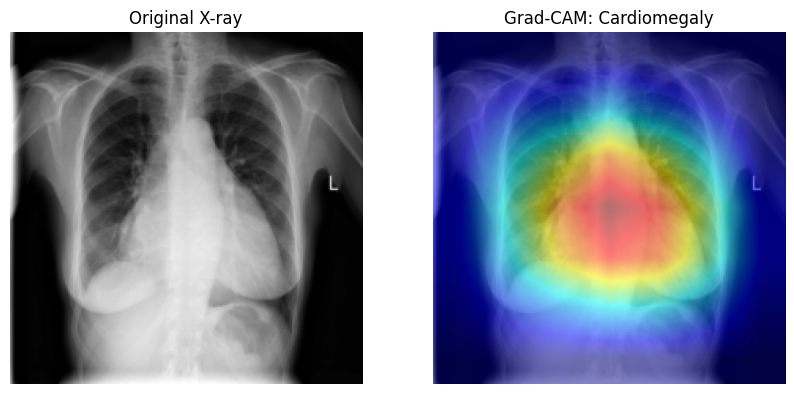

In [24]:
show_gradcam(197, 'Infiltration')
show_gradcam(278, 'Cardiomegaly')

In [25]:
best_emphysema = find_best_examples('Emphysema', n_candidates=500)
print(best_emphysema)

[(42, 0.9998016953468323), (118, 0.9996929168701172), (40, 0.9993674159049988)]


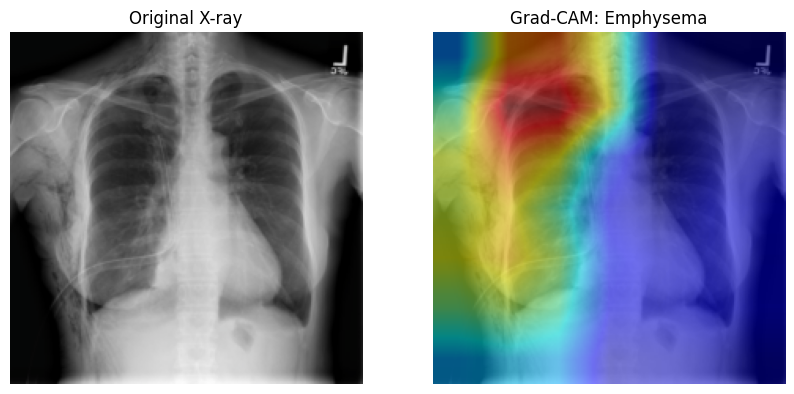

In [30]:
show_gradcam(best_emphysema[1][0], 'Emphysema')

In [31]:
!pip install gradio -q

# final app

In [32]:
import gradio as gr
import torch
import numpy as np
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def predict_and_explain(uploaded_image, selected_disease):
    # preprocess exactly like training/eval
    image = uploaded_image.convert('RGB')
    image_tensor = eval_transforms(image).unsqueeze(0).to('cuda')

    # get predictions for all 14 diseases
    with torch.no_grad():
        probs = torch.sigmoid(model(image_tensor))[0].cpu().numpy()

    results = {disease_names[i]: float(probs[i]) for i in range(len(disease_names))}

    # Grad-CAM for the selected disease
    disease_idx = disease_names.index(selected_disease)
    targets = [ClassifierOutputTarget(disease_idx)]
    grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0]

    img_np = image_tensor[0].permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    return results, visualization

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=[
        gr.Image(type="pil", label="Upload Chest X-Ray"),
        gr.Dropdown(choices=disease_names, value="Cardiomegaly", label="Disease to visualize with Grad-CAM"),
    ],
    outputs=[
        gr.Label(num_top_classes=5, label="Top Predicted Diseases"),
        gr.Image(label="Grad-CAM Heatmap"),
    ],
    title="Chest X-Ray Diagnosis Copilot",
    description="Upload a chest X-ray to get disease predictions and see where the model is focusing. Not a diagnostic tool — a research/educational demo.",
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c00d1d9b2dbdb60654.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
